Veri Setini Tanıma (EDA)

Sınıf Sayısı: 5
Sınıflar: ['Nail_psoriasis', 'SJS-TEN', 'Vitiligo', 'acne', 'hyperpigmentation']


,Image Count
SJS-TEN,1695
Vitiligo,1466
hyperpigmentation,1421
Nail_psoriasis,1350
acne,1271


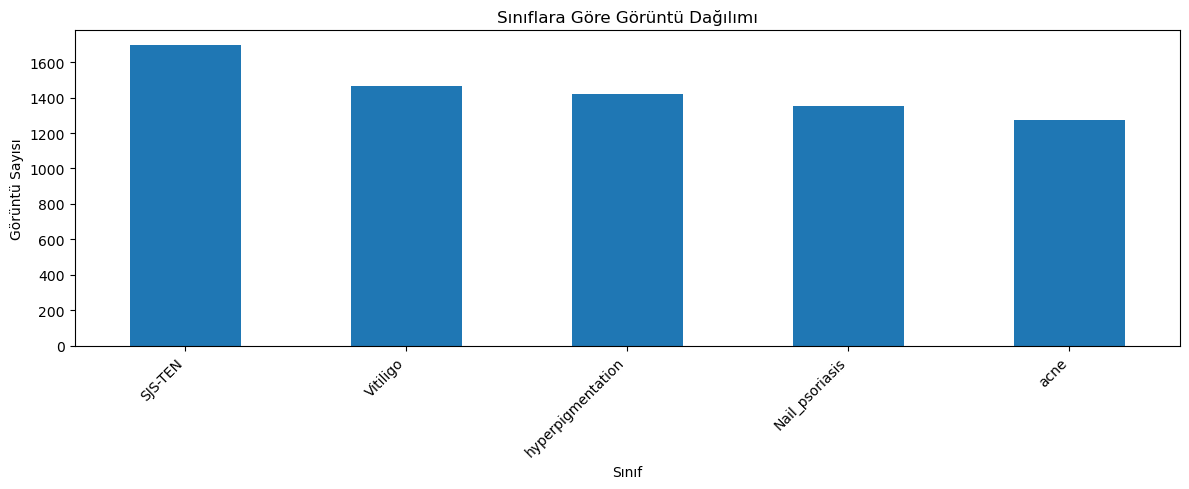

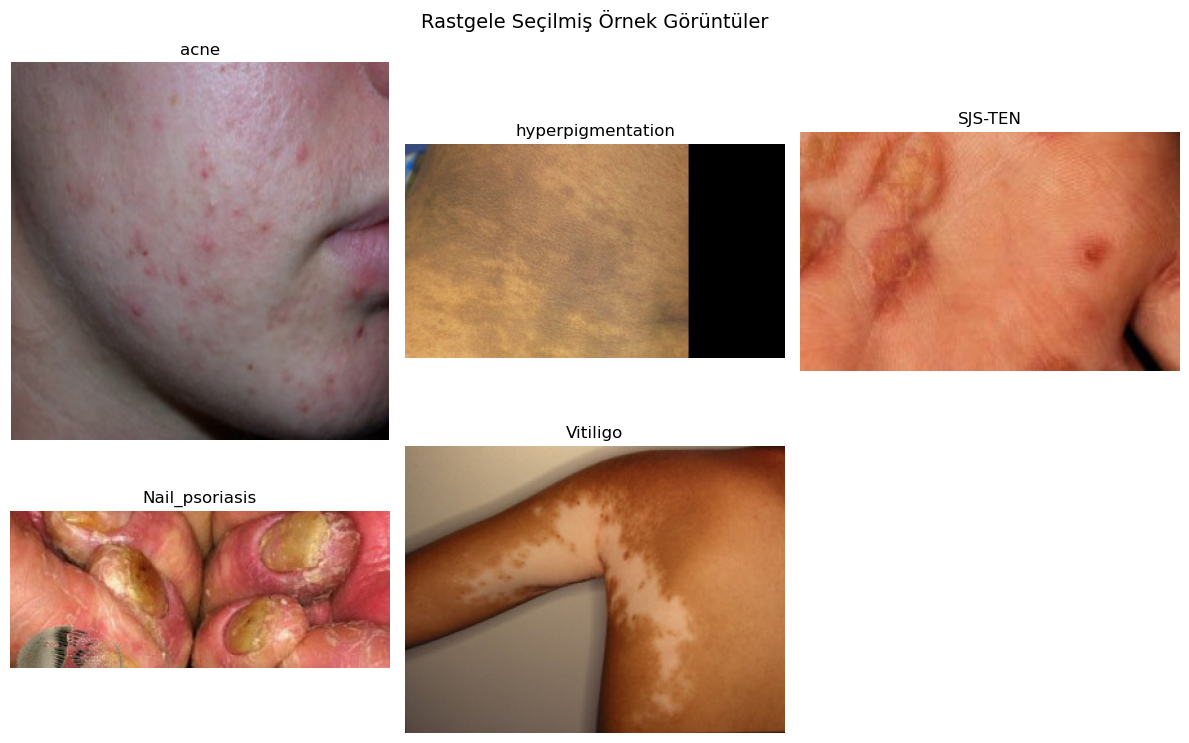

Örnek görüntü genişlikleri: [194, 294, 194, 224, 512]
Örnek görüntü yükseklikleri: [122, 222, 122, 224, 512]


In [3]:
# =========================================================
# EDA – Veri Setini Tanıma
# =========================================================

import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# -------------------------------
# 1. Dataset yolu
# -------------------------------
DATASET_DIR = "Skin Disease Classification Dataset"

# -------------------------------
# 2. Sınıf isimlerini al
# -------------------------------
class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Sınıf Sayısı:", len(class_names))
print("Sınıflar:", class_names)

# -------------------------------
# 3. Her sınıftaki görüntü sayısı
# -------------------------------
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    class_counts[cls] = len([
        img for img in os.listdir(cls_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

df_counts = pd.DataFrame.from_dict(
    class_counts, orient='index', columns=['Image Count']
).sort_values(by='Image Count', ascending=False)

display(df_counts)

# -------------------------------
# 4. Sınıf dağılım grafiği
# -------------------------------
plt.figure(figsize=(12,5))
df_counts['Image Count'].plot(kind='bar')
plt.title("Sınıflara Göre Görüntü Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü Sayısı")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Rastgele örnek görüntüler
# -------------------------------
plt.figure(figsize=(12,8))

for i, cls in enumerate(random.sample(class_names, min(6, len(class_names)))):
    cls_path = os.path.join(DATASET_DIR, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.suptitle("Rastgele Seçilmiş Örnek Görüntüler", fontsize=14)
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Görüntü boyutlarını inceleme
# -------------------------------
widths, heights = [], []

for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Örnek görüntü genişlikleri:", widths)
print("Örnek görüntü yükseklikleri:", heights)


Split Ayarları

In [4]:
# =========================================================
# Stratified Split (80/10/10) + Split Dosyalarını Kaydetme
# =========================================================

import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# -------------------------------
# 1) Dataset yolu (EDA'daki ile aynı)
# -------------------------------
DATASET_DIR = "Skin Disease Classification Dataset"

# -------------------------------
# 2) Split kayıt klasörü (artifacts/splits)
# -------------------------------
ARTIFACT_DIR = "artifacts"
SPLIT_DIR = os.path.join(ARTIFACT_DIR, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

train_csv = os.path.join(SPLIT_DIR, "train.csv")
val_csv   = os.path.join(SPLIT_DIR, "val.csv")
test_csv  = os.path.join(SPLIT_DIR, "test.csv")

# -------------------------------
# 3) Eğer split dosyaları zaten varsa, tekrar split yapma!
#    (Bu senin "tekrar tekrar eğitim gerekmesin" isteğin için kritik.)
# -------------------------------
if os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv):
    print("✅ Split dosyaları zaten var. Tekrar split yapmıyorum.")
    train_df = pd.read_csv(train_csv)
    val_df   = pd.read_csv(val_csv)
    test_df  = pd.read_csv(test_csv)
else:
    print("🧩 Split dosyaları yok. İlk kez stratified split yapıyorum...")

    # -------------------------------
    # 4) Tüm görüntü yollarını ve etiketlerini topla
    #    Burada her resim için: (path, label) üretiyoruz
    # -------------------------------
    class_names = sorted([
        d for d in os.listdir(DATASET_DIR)
        if os.path.isdir(os.path.join(DATASET_DIR, d))
    ])

    records = []
    for cls in class_names:
        cls_dir = os.path.join(DATASET_DIR, cls)
        # jpg / jpeg / png uzantılarını yakala
        img_paths = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            img_paths.extend(glob.glob(os.path.join(cls_dir, ext)))

        for p in img_paths:
            records.append({"filepath": p, "label": cls})

    df = pd.DataFrame(records)
    print("Toplam görüntü sayısı:", len(df))
    print("Toplam sınıf sayısı:", df["label"].nunique())

    # -------------------------------
    # 5) 80/10/10 split
    #    1) Önce train(80) + temp(20) ayırıyoruz
    #    2) Sonra temp(20) -> val(10) + test(10) şeklinde ikiye bölüyoruz
    #
    # Stratified = her parçanın içinde sınıf oranları korunur.
    # -------------------------------
    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,          # %20 (val+test)
        random_state=42,
        stratify=df["label"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,          # temp'in yarısı test -> %10
        random_state=42,
        stratify=temp_df["label"]
    )

    # -------------------------------
    # 6) Splitleri kaydet
    # -------------------------------
    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    print("✅ Split dosyaları kaydedildi:")
    print(" -", train_csv)
    print(" -", val_csv)
    print(" -", test_csv)

# -------------------------------
# 7) Kontrol: Kaç örnek düştü?
# -------------------------------
print("\n--- Split Boyutları ---")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# -------------------------------
# 8) Kontrol: Her splitte sınıf dağılımı benzer mi?
# -------------------------------
def show_distribution(name, df_part):
    dist = df_part["label"].value_counts().sort_index()
    print(f"\n{name} sınıf dağılımı:")
    print(dist)

show_distribution("TRAIN", train_df)
show_distribution("VAL", val_df)
show_distribution("TEST", test_df)


🧩 Split dosyaları yok. İlk kez stratified split yapıyorum...
Toplam görüntü sayısı: 7203
Toplam sınıf sayısı: 5
✅ Split dosyaları kaydedildi:
 - artifacts\splits\train.csv
 - artifacts\splits\val.csv
 - artifacts\splits\test.csv

--- Split Boyutları ---
Train: 5762
Val  : 720
Test : 721

TRAIN sınıf dağılımı:
label
Nail_psoriasis       1080
SJS-TEN              1356
Vitiligo             1172
acne                 1017
hyperpigmentation    1137
Name: count, dtype: int64

VAL sınıf dağılımı:
label
Nail_psoriasis       135
SJS-TEN              169
Vitiligo             147
acne                 127
hyperpigmentation    142
Name: count, dtype: int64

TEST sınıf dağılımı:
label
Nail_psoriasis       135
SJS-TEN              170
Vitiligo             147
acne                 127
hyperpigmentation    142
Name: count, dtype: int64


Kendi Modelim:

In [1]:
# =========================================================
# MyCNN - Kendi Modelim (Evrişimsel Sinir Ağı Mimarisi)
# Proje gereksinimi olan özgün model tasarımıdır.
# =========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = 5
IMG_SIZE = (224, 224)

# Model oluşturma fonksiyonu: Görüntü boyutunu ve sınıf sayısını alır.
def build_mycNN(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    # Giriş katmanı: 224x224 boyutunda, 3 kanallı (RGB) görüntüleri kabul eder.
    inputs = keras.Input(shape=input_shape)

    # -------- Block 1: Basit Özellik Çıkarımı (32 Filtre) --------
    # Amaç: Görüntüdeki kenar ve basit doku gibi temel görsel özellikleri yakalamak.
    x = layers.Conv2D(32, (3,3), padding="same")(inputs) # Evrişim: 3x3 pencerelerle özellik haritaları oluşturur.
    x = layers.BatchNormalization()(x) # Eğitimin kararlılığını ve hızını artırır.
    x = layers.Activation("relu")(x) # Doğrusal olmayan ilişki katar (ReLU aktivasyon fonksiyonu).

    x = layers.Conv2D(32, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2,2))(x) # Örnekleme (Downsampling): Veri boyutunu küçültür.
    x = layers.Dropout(0.10)(x) # Aşırı öğrenmeyi engellemek için %10 rastgele nöron kapatır.

    # -------- Block 2: Orta Seviye Özellik Çıkarımı (64 Filtre) --------
    # Amaç: İlk bloktan çıkan temel özellikleri birleştirerek daha karmaşık desenleri öğrenmek.
    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x) # Dropout oranı artırıldı.

    # -------- Block 3: Yüksek Seviye Özellik Çıkarımı (128 Filtre) --------
    # Amaç: Cilt lezyonlarına özgü karmaşık ve ayırt edici özellikleri (şekil, renk değişimleri) yakalamak.
    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.20)(x) # Dropout oranı daha da artırıldı.

    # -------- Classification Head (Sınıflandırma Katmanı) --------
    x = layers.GlobalAveragePooling2D()(x) # Uzamsal bilgiyi koruyarak tüm haritaların ortalamasını alır.
    x = layers.Dense(128, activation="relu")(x) # Tam Bağlantılı Katman (Fully Connected): Özellikleri sınıflandırmaya hazırlar.
    x = layers.Dropout(0.30)(x) # Sınıflandırma öncesinde ek aşırı öğrenme koruması.

    # Çıkış katmanı: 5 farklı hastalık sınıfı için olasılık dağılımı üretir.
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MyCNN")
    return model

# Modeli oluşturup özetini görelim
mycnn = build_mycNN()
mycnn.summary()

Model: "MyCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 305,957 (1.17 MB)

 Trainable params: 305,061 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

Eğitimden Önce Temel Ayarlar

In [7]:
# =========================================================
# tf.data Pipeline: train/val/test.csv -> tf.data.Dataset
# - Sadece TRAIN'de augmentation
# - Hepsinde normalize (0-1)
# =========================================================

import os
import pandas as pd
import tensorflow as tf

# -------------------------------
# 0) Temel ayarlar
# -------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 16          
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 5          

ARTIFACT_DIR = "artifacts"
SPLIT_DIR = os.path.join(ARTIFACT_DIR, "splits")

train_csv = os.path.join(SPLIT_DIR, "train.csv")
val_csv   = os.path.join(SPLIT_DIR, "val.csv")
test_csv  = os.path.join(SPLIT_DIR, "test.csv")

# -------------------------------
# 1) CSV'leri oku
# -------------------------------
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

# -------------------------------
# 2) Label mapping (string -> int)
#    Not: class_names sırası sabit olmalı ki tekrar tekrar aynı kalsın
# -------------------------------
class_names = sorted(train_df["label"].unique().tolist())
print("class_names:", class_names)

label_to_index = {name: i for i, name in enumerate(class_names)}
print("label_to_index:", label_to_index)

# DataFrame label sütununu int'e çevir
train_df["label_idx"] = train_df["label"].map(label_to_index)
val_df["label_idx"]   = val_df["label"].map(label_to_index)
test_df["label_idx"]  = test_df["label"].map(label_to_index)

# -------------------------------
# 3) Görsel okuma + preprocess fonksiyonu
# -------------------------------
def load_image(filepath, label_idx, training=False):
    # Dosyayı oku
    img_bytes = tf.io.read_file(filepath)
    # JPG/PNG fark etmez, otomatik decode
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # normalize: 0-1

    return img, tf.cast(label_idx, tf.int32)

# -------------------------------
# 4) Augmentation (sadece train)
#    "Yapay veri çeşitlendirme" -> overfitting azaltır
# -------------------------------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation")

def apply_aug(img, label):
    img = data_augmentation(img, training=True)
    return img, label

# -------------------------------
# 5) Dataset oluşturma fonksiyonu
# -------------------------------
def make_dataset(df, training=False, shuffle=False):
    paths = df["filepath"].values
    labels = df["label_idx"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=42, reshuffle_each_iteration=True)

    ds = ds.map(lambda p, y: load_image(p, y, training=training), num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(apply_aug, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

# -------------------------------
# 6) Train / Val / Test dataset'lerini üretiyoruz
# -------------------------------
train_ds = make_dataset(train_df, training=True, shuffle=True)
val_ds   = make_dataset(val_df, training=False, shuffle=False)
test_ds  = make_dataset(test_df, training=False, shuffle=False)

# -------------------------------
# 7) Hızlı kontrol
# -------------------------------
for images, labels in train_ds.take(1):
    print("Train batch images shape:", images.shape)  # (BATCH, 224, 224, 3)
    print("Train batch labels shape:", labels.shape)  # (BATCH,)
    print("Train labels sample:", labels.numpy()[:10])

print("✅ tf.data pipeline hazır!")


Train: 5762 Val: 720 Test: 721
class_names: ['Nail_psoriasis', 'SJS-TEN', 'Vitiligo', 'acne', 'hyperpigmentation']
label_to_index: {'Nail_psoriasis': 0, 'SJS-TEN': 1, 'Vitiligo': 2, 'acne': 3, 'hyperpigmentation': 4}
Train batch images shape: (16, 224, 224, 3)
Train batch labels shape: (16,)
Train labels sample: [2 4 2 1 0 0 1 1 3 0]
✅ tf.data pipeline hazır!


Ve Eğitim Kısmı:

In [9]:
# =========================================================
# TEK HÜCRE: 11 Model Eğitimi + Kayıt + Test Değerlendirme
# Models: MyCNN, VGG16, VGG19, ResNet50, ResNet101V2, InceptionV3,
#         Xception, DenseNet121, MobileNetV2, EfficientNetB0, EfficientNetB3
# =========================================================

import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report, f1_score, cohen_kappa_score, accuracy_score

# -----------------------------
# 0) Güvenli ayarlar 
# -----------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

FORCE_TRAIN = False      
MAX_EPOCH = 30
BATCH_SIZE = 16          
BASE_LR = 1e-4

# train_ds / val_ds / test_ds zaten önceki hücreden gelmiş olmalı
# class_names da önceki hücreden gelmiş olmalı
NUM_CLASSES = len(class_names)

# -----------------------------
# 1) Artifacts klasörleri
# -----------------------------
ARTIFACT_DIR = "artifacts"
MODEL_DIR    = os.path.join(ARTIFACT_DIR, "models")
HIST_DIR     = os.path.join(ARTIFACT_DIR, "histories")
METRIC_DIR   = os.path.join(ARTIFACT_DIR, "reports")
FIG_DIR      = os.path.join(ARTIFACT_DIR, "figures")  # şimdilik cm kaydederiz

for d in [MODEL_DIR, HIST_DIR, METRIC_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# -----------------------------
# 2) CSVLogger çıktısından "best epoch" metriklerini çekme
#    Best kriteri: val_loss minimum (checkpoint monitor ile aynı)
# -----------------------------
def get_best_epoch_metrics_from_csv(csvlog_path):
    hist = pd.read_csv(csvlog_path)

    if "val_loss" not in hist.columns:
        raise ValueError(
            f"val_loss kolonu bulunamadı: {csvlog_path}. Kolonlar: {hist.columns.tolist()}"
        )

    best_row_idx = int(hist["val_loss"].idxmin())
    best_row = hist.iloc[best_row_idx]

    out = {
        "best_epoch": int(best_row_idx + 1),
        "best_val_loss": float(best_row["val_loss"]),
        "best_val_accuracy": None,
        "best_train_loss": None,
        "best_train_accuracy": None
    }

    if "val_accuracy" in hist.columns:
        out["best_val_accuracy"] = float(best_row["val_accuracy"])
    if "loss" in hist.columns:
        out["best_train_loss"] = float(best_row["loss"])
    if "accuracy" in hist.columns:
        out["best_train_accuracy"] = float(best_row["accuracy"])

    return out

# -----------------------------
# 3) Callback'ler (erken durdurma + LR düşürme + en iyi modeli kaydetme)
# -----------------------------
def make_callbacks(model_name):
    ckpt_path = os.path.join(MODEL_DIR, model_name, "best.keras")
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    csvlog_path = os.path.join(HIST_DIR, f"{model_name}_history.csv")

    cbs = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path, monitor="val_loss", save_best_only=True, verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.CSVLogger(csvlog_path, append=False)
    ]
    return cbs, ckpt_path, csvlog_path

# -----------------------------
# 4) Base model builder (Transfer Learning)
# -----------------------------
def build_tl_model(base_model, model_name, input_shape=(224,224,3), num_classes=NUM_CLASSES, dropout=0.3):
    base_model.trainable = False  # Stage-1 freeze

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model

# -----------------------------
# 5) Model factory
# -----------------------------
def get_models():
    models = []

    # 1) MyCNN (benim modelim)
    models.append(("MyCNN", build_mycNN(input_shape=(224,224,3), num_classes=NUM_CLASSES)))

    from tensorflow.keras.applications import (
        VGG16, VGG19, ResNet50, ResNet101V2, InceptionV3, Xception,
        DenseNet121, MobileNetV2, EfficientNetB0, EfficientNetB3
    )

    bases = [
        ("VGG16",         VGG16(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("VGG19",         VGG19(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("ResNet50",      ResNet50(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("ResNet101V2",   ResNet101V2(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("InceptionV3",   InceptionV3(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("Xception",      Xception(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("DenseNet121",   DenseNet121(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("MobileNetV2",   MobileNetV2(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("EfficientNetB0",EfficientNetB0(include_top=False, weights="imagenet", input_shape=(224,224,3))),
        ("EfficientNetB3",EfficientNetB3(include_top=False, weights="imagenet", input_shape=(224,224,3))),
    ]

    for name, base in bases:
        m = build_tl_model(base, name, input_shape=(224,224,3), num_classes=NUM_CLASSES, dropout=0.3)
        models.append((name, m))

    return models

# -----------------------------
# 6) Compile helper
# -----------------------------
def compile_model(model, lr=BASE_LR):
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

# -----------------------------
# 7) Test evaluation helper
# -----------------------------
def evaluate_on_test(model, test_ds):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        y_true.extend(y_batch.numpy().tolist())
        y_pred.extend(pred_labels.tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    cls_rep = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return acc, f1m, kappa, cm, cls_rep

# -----------------------------
# 8) Eğitim döngüsü
# -----------------------------
all_results = []
models = get_models()

print(f"Toplam model sayısı: {len(models)}  (beklenen: 11)")
print("Sınıflar:", class_names)

start_all = time.time()

for model_name, model in models:
    print("\n" + "="*70)
    print(f"MODEL: {model_name}")
    print("="*70)

    # Kayıt yolları
    cbs, ckpt_path, csvlog_path = make_callbacks(model_name)
    metrics_path = os.path.join(METRIC_DIR, f"{model_name}_metrics.json")
    cm_path = os.path.join(FIG_DIR, f"{model_name}_confusion_matrix.npy")

    # Eğitim veya yükleme
    trained_now = False
    if os.path.exists(ckpt_path) and (not FORCE_TRAIN):
        print(f"✅ Checkpoint bulundu, eğitim atlanıyor: {ckpt_path}")
        model = keras.models.load_model(ckpt_path)
    else:
        compile_model(model, lr=BASE_LR)

        t0 = time.time()
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=MAX_EPOCH,
            callbacks=cbs,
            verbose=1
        )
        train_time = time.time() - t0
        trained_now = True

        if os.path.exists(ckpt_path):
            model = keras.models.load_model(ckpt_path)

    # Best epoch metrikleri
    if os.path.exists(csvlog_path):
        best_metrics = get_best_epoch_metrics_from_csv(csvlog_path)
    else:
        best_metrics = {
            "best_epoch": None,
            "best_val_loss": None,
            "best_val_accuracy": None,
            "best_train_loss": None,
            "best_train_accuracy": None
        }

    # Test değerlendirme
    test_acc, test_f1m, test_kappa, cm, cls_rep = evaluate_on_test(model, test_ds)

    # CM kaydet
    np.save(cm_path, cm)

    # Metrikleri kaydet
    out = {
        "model": model_name,

        # Best epoch (val_loss minimum)
        **best_metrics,

        # Test metrikleri
        "test_accuracy": float(test_acc),
        "test_f1_macro": float(test_f1m),
        "test_kappa": float(test_kappa),

        # Diğer kayıtlar
        "confusion_matrix_npy": cm_path,
        "classification_report": cls_rep
    }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)

    # Özet satır
    print(
        f"BEST: epoch={best_metrics['best_epoch']} | "
        f"val_loss={best_metrics['best_val_loss']} | val_acc={best_metrics['best_val_accuracy']}"
    )
    print(f"TEST Acc: {test_acc:.4f} | F1(macro): {test_f1m:.4f} | Kappa: {test_kappa:.4f}")
    print(f"✅ metrics saved -> {metrics_path}")
    print(f"✅ cm saved -> {cm_path}")

    all_results.append({
        "model": model_name,
        "best_epoch": best_metrics["best_epoch"],
        "best_val_loss": best_metrics["best_val_loss"],
        "best_val_accuracy": best_metrics["best_val_accuracy"],
        "test_accuracy": test_acc,
        "test_f1_macro": test_f1m,
        "test_kappa": test_kappa,
        "metrics_path": metrics_path
    })

# Sonuç tablosunu kaydet
results_df = pd.DataFrame(all_results).sort_values(by="test_accuracy", ascending=False)
results_csv = os.path.join(METRIC_DIR, "all_models_summary.csv")
results_df.to_csv(results_csv, index=False)

print("\n" + "="*70)
print("TÜM MODELLER BİTTİ ✅")
print("Özet tablo:", results_csv)
print(results_df)

print(f"\nToplam süre (dk): {(time.time() - start_all)/60:.1f}")


Toplam model sayısı: 11  (beklenen: 11)
Sınıflar: ['Nail_psoriasis', 'SJS-TEN', 'Vitiligo', 'acne', 'hyperpigmentation']

MODEL: MyCNN
Epoch 1/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4105 - loss: 1.3958   
Epoch 1: val_loss improved from None to 2.02582, saving model to artifacts\models\MyCNN\best.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 765s 2s/step - accuracy: 0.4616 - loss: 1.2976 - val_accuracy: 0.1903 - val_loss: 2.0258 - learning_rate: 1.0000e-04
Epoch 2/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5149 - loss: 1.1910   
Epoch 2: val_loss improved from 2.02582 to 1.22210, saving model to artifacts\models\MyCNN\best.keras
361/361 ━━━━━━━━━━━━━━━━━━━━ 739s 2s/step - accuracy: 0.5408 - loss: 1.1512 - val_accuracy: 0.4889 - val_loss: 1.2221 - learning_rate: 1.0000e-04
Epoch 3/30
361/361 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5787 - loss: 1.0866   
Epoch 3: val_loss did not improve from 1.22210
361/361 ━━━━━━━━━━━━━━━━━━━━ 745s 2s/step - accuracy: 0.5831 

In [10]:
# =========================================================
# ROC–AUC (Multi-class, One-vs-Rest)
# - Kayıtlı best.keras modelleri kullanılır
# =========================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -----------------------------
# 0) Ayarlar
# -----------------------------
ARTIFACT_DIR = "artifacts"
MODEL_DIR = os.path.join(ARTIFACT_DIR, "models")
FIG_DIR = os.path.join(ARTIFACT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

NUM_CLASSES = len(class_names)

# ROC çizilecek modeller (en iyi olanlar)
ROC_MODELS = [
    "ResNet101V2",
    "InceptionV3",
    "DenseNet121",
    "MobileNetV2"   
]

# -----------------------------
# 1) Test setinden gerçek etiketleri ve olasılıkları alalım
# -----------------------------
def get_test_labels_and_probs(model, test_ds):
    y_true = []
    y_prob = []

    for x_batch, y_batch in test_ds:
        probs = model.predict(x_batch, verbose=0)
        y_true.extend(y_batch.numpy())
        y_prob.extend(probs)

    return np.array(y_true), np.array(y_prob)

# -----------------------------
# 2) ROC–AUC hesaplayıp çizelim
# -----------------------------
for model_name in ROC_MODELS:
    print(f"\nROC–AUC hesaplanıyor: {model_name}")

    model_path = os.path.join(MODEL_DIR, model_name, "best.keras")
    model = keras.models.load_model(model_path)

    y_true, y_prob = get_test_labels_and_probs(model, test_ds)

    # One-vs-Rest için label binarize
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)

    # -----------------------------
    # 3) Plot
    # -----------------------------
    plt.figure(figsize=(7, 6))
    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"Macro-average ROC (AUC = {macro_auc:.3f})",
        linewidth=2
    )

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.legend(loc="lower right")

    save_path = os.path.join(FIG_DIR, f"roc_{model_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ ROC kaydedildi: {save_path}")
    print(f"📊 Macro AUC ({model_name}): {macro_auc:.4f}")

print("\nTÜM ROC–AUC GRAFİKLERİ HAZIR ✅")



ROC–AUC hesaplanıyor: ResNet101V2
✅ ROC kaydedildi: artifacts\figures\roc_ResNet101V2.png
📊 Macro AUC (ResNet101V2): 0.9911

ROC–AUC hesaplanıyor: InceptionV3
✅ ROC kaydedildi: artifacts\figures\roc_InceptionV3.png
📊 Macro AUC (InceptionV3): 0.9801

ROC–AUC hesaplanıyor: DenseNet121
✅ ROC kaydedildi: artifacts\figures\roc_DenseNet121.png
📊 Macro AUC (DenseNet121): 0.9786

ROC–AUC hesaplanıyor: MobileNetV2
✅ ROC kaydedildi: artifacts\figures\roc_MobileNetV2.png
📊 Macro AUC (MobileNetV2): 0.9846

TÜM ROC–AUC GRAFİKLERİ HAZIR ✅


In [12]:
# =========================================================
# Confusion Matrix 
# - artifacts/figures/*.npy dosyalarından okunur
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ARTIFACT_DIR = "artifacts"
FIG_DIR = os.path.join(ARTIFACT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# CM çizilecek modeller (en başarılılar)
CM_MODELS = [
    "ResNet101V2",
    "InceptionV3",
    "DenseNet121",
    "MobileNetV2",
    "MyCNN"   
]

for model_name in CM_MODELS:
    cm_path = os.path.join(FIG_DIR, f"{model_name}_confusion_matrix.npy")

    if not os.path.exists(cm_path):
        print(f"❌ CM bulunamadı: {cm_path}")
        continue

    cm = np.load(cm_path)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – {model_name}")

    save_path = os.path.join(FIG_DIR, f"cm_{model_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Confusion Matrix kaydedildi: {save_path}")

print("\nTÜM CONFUSION MATRIX GRAFİKLERİ HAZIR ✅")


✅ Confusion Matrix kaydedildi: artifacts\figures\cm_ResNet101V2.png
✅ Confusion Matrix kaydedildi: artifacts\figures\cm_InceptionV3.png
✅ Confusion Matrix kaydedildi: artifacts\figures\cm_DenseNet121.png
✅ Confusion Matrix kaydedildi: artifacts\figures\cm_MobileNetV2.png
✅ Confusion Matrix kaydedildi: artifacts\figures\cm_MyCNN.png

TÜM CONFUSION MATRIX GRAFİKLERİ HAZIR ✅


In [13]:
# =========================================================
# Model Karşılaştırma Tablosu (Accuracy, F1, Kappa, Best Val, AUC)
# =========================================================

import os
import pandas as pd
import numpy as np

ARTIFACT_DIR = "artifacts"
REPORT_DIR = os.path.join(ARTIFACT_DIR, "reports")
FINAL_PATH = os.path.join(REPORT_DIR, "final_comparison_table.csv")

summary_path = os.path.join(REPORT_DIR, "all_models_summary.csv")
df = pd.read_csv(summary_path)

# ROC AUC değerleri 
roc_auc_map = {
    "ResNet101V2": 0.9911,
    "InceptionV3": 0.9801,
    "DenseNet121": 0.9786,
    "MobileNetV2": 0.9846
}

df["roc_auc_macro"] = df["model"].map(roc_auc_map)

# Daha okunur sıralama
df = df.sort_values(by=["test_accuracy"], ascending=False).reset_index(drop=True)

# Kolon sırası 
cols = [
    "model",
    "best_epoch",
    "best_val_loss",
    "best_val_accuracy",
    "test_accuracy",
    "test_f1_macro",
    "test_kappa",
    "roc_auc_macro",
    "metrics_path"
]
df = df[cols]

# Yuvarlama 
for c in ["best_val_loss","best_val_accuracy","test_accuracy","test_f1_macro","test_kappa","roc_auc_macro"]:
    df[c] = df[c].astype(float).round(4)

df.to_csv(FINAL_PATH, index=False)

print("✅ Final karşılaştırma tablosu kaydedildi:", FINAL_PATH)
print(df)

✅ Final karşılaştırma tablosu kaydedildi: artifacts\reports\final_comparison_table.csv
             model  best_epoch  best_val_loss  best_val_accuracy  \
0      ResNet101V2          29         0.2222             0.9194   
1      InceptionV3          30         0.3500             0.8708   
2      DenseNet121          30         0.3488             0.8903   
3      MobileNetV2          29         0.3171             0.8875   
4         Xception          30         0.3688             0.8792   
5            MyCNN          10         0.7776             0.7139   
6            VGG16          30         1.0213             0.6153   
7            VGG19          30         1.1141             0.5778   
8         ResNet50          30         1.5055             0.3597   
9   EfficientNetB0          30         1.6045             0.2347   
10  EfficientNetB3          28         1.6011             0.2347   

    test_accuracy  test_f1_macro  test_kappa  roc_auc_macro  \
0          0.9140         0.9149 

In [14]:
#son